In this case study, you will assume the role of a data scientist at a retail electronic store chain. The primary product sold by the store is laptops. The store maintains a stock of laptops to cater to both walk-in and online customers. However, holding excessive inventory incurs costs, while having insufficient stock results in missed sales opportunities. To strike the right balance, you need to forecast the demand for laptops and develop an ordering plan to minimise costs. Your task is to develop an analytics solution to minimise the store's cost by aligning it with customer demand. Specifically, you will focus on optimising the inventory of laptops in the store and managing the logistics of laptop orders.

*Inventory Costs*: Inventory costs are incurred based on the number of laptops remaining in the store by the end of each month. Each laptop in inventory incurs a cost of $1.0 per month.

*Ordering Laptops*: A new batch of laptops can be ordered and delivered to the store at the beginning of each month. However, ordering laptops incurs a fixed cost of $2000 per order to cover all logistics expenses, regardless of the quantity ordered. The store can order up to 6000 laptops per month.

*Demand Forecasting*: Previous research indicates a strong correlation between the Google Trend Index for the keyword "laptop" and the actual demand for laptops at the store. To estimate customer demand, a simple model has been developed: customer demand = 100 + 20 * Google_trend_index_laptop. Your task is to leverage this model to forecast customer demand.

*Objective*: Your goal is to develop a laptop ordering plan for the next four months that minimises the combined inventory and logistic costs while satisfying customer demands.

 Forecasting Customer Demand for Laptops

To forecast customer demand for laptops, we will leverage the Google Trends Index data. To retrieve data from Google Trends, we will use a library called PyTrends. You can execute the code cell below to install the library.

In [ ]:
# Install pytrends
%%capture
!pip install pytrends

In [ ]:
import pandas as pd
from pytrends.request import TrendReq

# Set keyword and timeframe
keyword = "laptop"
timeframe = "2014-05-01 2024-05-01"

# Initialize pytrends object
pytrends = TrendReq()

# Build payload and retrieve data
pytrends.build_payload(kw_list=[keyword], timeframe=timeframe)
df_laptop = pytrends.interest_over_time()

# Display the first several rows of the data
df_laptop.head()

,laptop,isPartial
date,,
2014-05-01,61,False
2014-06-01,60,False
2014-07-01,65,False
2014-08-01,72,False
2014-09-01,68,False


The dataset provides a series of laptop index values recorded over consecutive months. The "laptop" column indicates the value of the laptop index for each corresponding date. The "isPartial" column indicates whether the data for a particular date is complete or partial.

Prior to constructing a time series forecasting model, it is essential to conduct exploratory data analysis (EDA) to gain insights into the dataset and perform any required data cleansing.

In [ ]:
# Display a summary of the columns and data types.
df_laptop.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121 entries, 2014-05-01 to 2024-05-01
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   laptop     121 non-null    int64
 1   isPartial  121 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 2.0 KB


The dataset does not contain any missing values or categorical data. However, it is currently indexed by datetime. To facilitate analysis and further manipulation of the dataset, let's reset the index.

In [ ]:
# Reset the index of the dataset
df_laptop.reset_index(inplace=True)

# Display the first several rows of the data
df_laptop.head()

,date,laptop,isPartial
0,2014-05-01,61,False
1,2014-06-01,60,False
2,2014-07-01,65,False
3,2014-08-01,72,False
4,2014-09-01,68,False


We can proceed to construct a time series forecasting model, specifically for predicting the laptop index. To begin, let's visualize the laptop index by employing a line chart.

In [ ]:
import plotly.express as px

# Creating a line chart using Plotly Express
fig = px.line(df_laptop, x='date', y='laptop', title='Laptop Index')

# Display the chart
fig.show()

To develop a time series forecasting model, we will utilize the Prophet package developed by Facebook. To install the Prophet package, you can execute the following code.

In [ ]:
# Install Prophet
%%capture
!pip install prophet

 1.1**: Build a time series forecasting model to predict the Google Trends Index for laptops for the next four months. This could include selecting evaluation metrics, tunning hyper-parameters, visualising key model components and forecasting results, etc.

In [ ]:
# Import  libraries
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.graph_objects as go

# Prepare the data for Prophet
df_laptop = df_laptop.rename(columns={'date': 'ds', 'laptop': 'y'})

# Hyperparameter tuning and adding seasonality components
params = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 5.0, 10.0],
    'yearly_seasonality': [True],
    'weekly_seasonality': [True],
    'daily_seasonality': [False]
}

# Grid search to find the best hyperparameters
best_params = None
best_mae = float('inf')
best_rmse = float('inf')
best_r2 = float('-inf')

for seasonality_mode in params['seasonality_mode']:
    for changepoint_prior_scale in params['changepoint_prior_scale']:
        for seasonality_prior_scale in params['seasonality_prior_scale']:
            for yearly_seasonality in params['yearly_seasonality']:
                for weekly_seasonality in params['weekly_seasonality']:
                    # Initialize the Prophet model with hyperparameters
                    model = Prophet(
                        seasonality_mode=seasonality_mode,
                        changepoint_prior_scale=changepoint_prior_scale,
                        seasonality_prior_scale=seasonality_prior_scale,
                        yearly_seasonality=yearly_seasonality,
                        weekly_seasonality=weekly_seasonality,
                        daily_seasonality=False
                    )
                    model.fit(df_laptop)

                    # Make predictions
                    future = model.make_future_dataframe(periods=4*30, freq='D')
                    forecast = model.predict(future)

                    # Calculate evaluation metrics
                    predicted = forecast['yhat'][-4*30:].values
                    actual = df_laptop['y'][-4*30:].values

                    mae = mean_absolute_error(actual, predicted)
                    rmse = np.sqrt(mean_squared_error(actual, predicted))
                    r2 = r2_score(actual, predicted)

                    # Update best parameters if current model is better
                    if mae < best_mae:
                        best_mae = mae
                        best_rmse = rmse
                        best_r2 = r2
                        best_params = {
                            'seasonality_mode': seasonality_mode,
                            'changepoint_prior_scale': changepoint_prior_scale,
                            'seasonality_prior_scale': seasonality_prior_scale,
                            'yearly_seasonality': yearly_seasonality,
                            'weekly_seasonality': weekly_seasonality,
                            'rmse': rmse,
                            'r2': r2
                        }

print(f"Best Parameters: {best_params}")
print(f"Mean Absolute Error (MAE): {best_mae}")
print(f"Root Mean Squared Error (RMSE): {best_rmse}")
print(f"R²: {best_r2}")

# Train the best model with tuned hyperparameters
model = Prophet(
    seasonality_mode=best_params['seasonality_mode'],
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    yearly_seasonality=best_params['yearly_seasonality'],
    weekly_seasonality=best_params['weekly_seasonality'],
    daily_seasonality=False
)
model.fit(df_laptop)

# Create a dataframe for future dates (next 4 months)
future = model.make_future_dataframe(periods=4*30, freq='D')

# Forecast future values
forecast = model.predict(future)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp2kl1c3zv/cuoftdvy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2kl1c3zv/0mjl7uqm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17819', 'data', 'file=/tmp/tmp2kl1c3zv/cuoftdvy.json', 'init=/tmp/tmp2kl1c3zv/0mjl7uqm.json', 'output', 'file=/tmp/tmp2kl1c3zv/prophet_modeld5ldhu5m/prophet_model-20240608120649.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:06:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:06:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
12:06:49 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2kl1c3zv/56ih27n5.json
DE

Best Parameters: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 0.01, 'yearly_seasonality': True, 'weekly_seasonality': True, 'rmse': 9.884409431228613, 'r2': 0.06532464639651958}
Mean Absolute Error (MAE): 7.9536635621120775
Root Mean Squared Error (RMSE): 9.884409431228613
R²: 0.06532464639651958


In [ ]:
# Plot the forecast using Plotly
fig = go.Figure()

# Add actual data
fig.add_trace(go.Scatter(x=df_laptop['ds'], y=df_laptop['y'], mode='markers', name='Actual'))

# Add forecasted data
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines', name='Forecast'))

# Add upper and lower confidence intervals
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', fill='tonexty', name='Upper Confidence Interval', line=dict(color='lightgrey')))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', fill='tonexty', name='Lower Confidence Interval', line=dict(color='lightgrey')))

# Set title and labels
fig.update_layout(title='Laptop Google Trends Index Forecast',
                  xaxis_title='Date',
                  yaxis_title='Google Trends Index')

# Show the plot
fig.show()


 1.2**: Estimate the customer demand for laptops at the store over the next four months based on the forecasted Google Trends Index for laptops. Round the estimated demand to the nearest integer value using the `round()` function.

In [ ]:
# prompt: Estimate the customer demand for laptops at the store over the next four months based on the forecasted Google Trends Index for laptops. Round the estimated demand to the nearest integer value using the round() function.

# Extract the forecasted Google Trends Index for the next four months
forecast_laptop_index = forecast['yhat'][-4*30:].values

# Estimate customer demand by multiplying the forecasted Google Trends Index by 20 and adding 100
estimated_demand = np.round(100 + 20 * forecast_laptop_index)

# Print the estimated demand for each month
for i in range(4):
    print(f"Month {i+1}: {estimated_demand[i]} laptops")


Month 1: 1525.0 laptops
Month 2: 1517.0 laptops
Month 3: 1514.0 laptops
Month 4: 1518.0 laptops


 Inventory Optimisation

The store's laptop inventory at the end of the current month is 2015 units. Based on the forecasted customer demand, create a strategic plan for the store to order laptops for the next four months. The objective is to minimise the combined costs of inventory and logistics, while ensuring that customer demands are met.

To solve the inventory optimisation problem, our first step is to model it as an integer linear program and establish a mathematical model.

*Decision variables*:

* $x_t$ represents the number of laptops ordered in month $t$, where $t$ ranges from 1 to 4.
* $y_t$ is a binary variable, indicating whether laptops will be ordered in month $t$, where $t$ ranges from 1 to 4.
* $s_t$ represents the number of laptops remaining in the store at the end of month $t$, where $t$ ranges from 1 to 4.


*Ordering costs*: Every month, when an order for laptops is placed, a fixed cost of \$2000 is incurred to cover logistics expenses. In other words, if $y_t = 1$ in month $t$, the ordering cost amounts to \$2000. Conversely, if $y_t = 0$, there is no ordering cost. Consequently, the ordering cost in month $t$ is $2000y_t$.
* The total ordering costs over the four months can be expressed as $\sum_{t=1}^{4} 2000y_t$, which is a compact way to write $2000 y_1 + 2000 y_2 + 2000 y_3 + 2000 y_4$.

*Inventory costs*: Inventory costs are incurred based on the number of laptops remaining in the store by the end of each month ($s_t$). Each laptop in inventory incurs a cost of $1.0 per month.

**Task 2.1**: Write down the inventory costs for the four months.
Total Inventory Costs=s1+s2​+s3+s4

*Objective function*: The objective function of this problem is to minimise the sum of the inventory and logistic costs over the four months.

 2.2**: Write down the objective function for this problem.
Objective Function Minimize Z=2000y1​+2000y2​+2000y3​+2000y4+s1​+s2​+s3​+s

*Ordering constraint*: The decision variable $x_t$ represents the number of laptops ordered in month $t$, while the binary variable $y_t$ indicates whether laptops will be ordered in that month. Therefore, if $y_t = 0$, the value of $x_t$ should be 0, indicating that no laptops can be ordered. Conversely, if $y_t = 1$, $x_t$ is constrained to be less than or equal to 6000, as a maximum of 6000 laptops can be ordered per month. To represent this relationship, we can utilize the following constraint:
* $x_t \le 6000 y_t$, for $t$ ranging from 1 to 4.





*Balance constraint*: Let $d_t$ represent the forecasted demand for laptops at the store in month $t$, where $t$ ranges from 1 to 4. The store's laptop inventory at the start of month 1 is 2015 units. In other words, the number of laptops remaining in the store at the end of month 0 is 2015 (i.e., $s_0 = 2015$). There exists a relationship between the number of laptops remaining in the store at the end of month $t$ ($s_t$), the number of laptops ordered ($x_t$), and the number of laptops sold (i.e., demand $d_t$) at month $t$.

 2.3**: Write down the constraint to capture this relationship.
Balance Constraints:
s1 =s0+x1-d1
st =st-1+xt-dt,∀t =2,3,4

*Demand constraint*: Each month, it is essential to ensure that the laptops at the store satisfy the customer demand. In other words, there should never be a situation where a customer is unable to purchase a laptop from the store.

**: Write down the constraint to satisfy the customer demand.
Demand constraint
st
≥dt
​∀t=1,2,3,4

***Mathematical Model***:

**: Write down the integer linear program model for the inventory optimisation problem.

Optimization model:

Decision Variables:

Xt:Number of laptop in month T (where t range from 1 to 4)

Yt:Binary variable indicating whether laptops will be ordered in month t

St: Number of laptop remaining in the store at the end of month t

Total Ordering Cost:
 2000y1+2000y2+2000y3+2000y4

Total inventory cost = S1+S2+S3+S4

Objective Function : 2000y1+2000y2+2000y3+2000y4+ S1+S2+S3+S4

Ordering Constraint: xt <=6000yt, t ranging 1 from one to 4

Balance constraint :S1= S0+X1-D1 =>St-1+xt-dt, t ranging from 2 to 4

Demand constraint = St >=Dt ,t ranging from 1 to 4

Initial inventory S0 =2015



To create an optimisation model for solving this problem, we will employ the OR-Tools package developed by Google. To install the OR-Tools package, you can execute the following code:

In [ ]:
#Install Google OR-Tools
%%capture
!pip install ortools

 Develop an optimisation model using Google OR-Tools to solve the inventory optimisation problem and generate the optimal ordering plan for laptops over the next four months.

In [ ]:
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt

# Create the solver
solver = pywraplp.Solver.CreateSolver('SCIP')
if not solver:
    raise Exception("Solver not created.")

# Decision variables
x = [solver.IntVar(0, 6000, f'x_{t}') for t in range(4)]
y = [solver.BoolVar(f'y_{t}') for t in range(4)]
s = [solver.IntVar(0, solver.infinity(), f's_{t}') for t in range(4)]

# Initial inventory
s_0 = 2015

# Forecasted demand.
forecasted_demand = [1564, 1571, 1587, 1651]

# Constraints
# Inventory balance constraints
solver.Add(s[0] == s_0 + x[0] - forecasted_demand[0])
for t in range(1, 4):
    solver.Add(s[t] == s[t-1] + x[t] - forecasted_demand[t])

# Order quantity constraints
for t in range(4):
    solver.Add(x[t] <= 6000 * y[t])
    solver.Add(x[t] >= 0)

# Demand constraints
for t in range(4):
    solver.Add(s[t] >= 0)  # Ensure non-negative inventory

# Objective function: Minimize total cost
ordering_costs = solver.Sum([2000 * y[t] for t in range(4)])
inventory_costs = solver.Sum([s[t] for t in range(4)])
total_costs = ordering_costs + inventory_costs
solver.Minimize(total_costs)

# Solve the problem
status = solver.Solve()

# Extract results
if status == pywraplp.Solver.OPTIMAL:
    orders = [x[t].solution_value() for t in range(4)]
    inventory_levels = [s[t].solution_value() for t in range(4)]
    total_cost = solver.Objective().Value()
    print('Solution:')
    for t in range(4):
        print(f'Month {t+1}: Order {orders[t]} laptops, Inventory at the end of the month: {inventory_levels[t]} units')
    print(f'Total cost: {total_cost}')
else:
    raise Exception("The problem does not have an optimal solution.")


Solution:
Month 1: Order -0.0 laptops, Inventory at the end of the month: 451.0 units
Month 2: Order 2707.0 laptops, Inventory at the end of the month: 1587.0 units
Month 3: Order -0.0 laptops, Inventory at the end of the month: -0.0 units
Month 4: Order 1651.0 laptops, Inventory at the end of the month: 0.0 units
Total cost: 6037.999999999998


 Visualise the optimal ordering plan for laptops with the forecasted customer demand and the inventory level over the next four months.

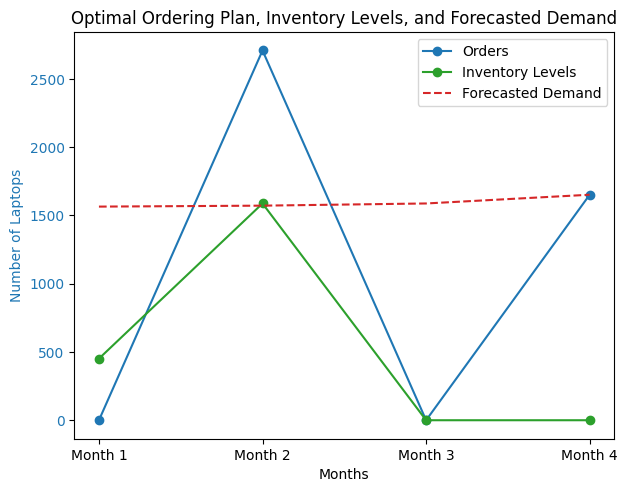

In [ ]:
 #Visualization
months = ['Month 1', 'Month 2', 'Month 3', 'Month 4']
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Months')
ax1.set_ylabel('Number of Laptops', color=color)
ax1.plot(months, orders, label='Orders', color=color, marker='o')
ax1.plot(months, inventory_levels, label='Inventory Levels', color='tab:green', marker='o')
ax1.plot(months, forecasted_demand, label='Forecasted Demand', color='tab:red', linestyle='dashed')
ax1.tick_params(axis='y', labelcolor=color)

# Add a legend
fig.tight_layout()
plt.legend()
plt.title('Optimal Ordering Plan, Inventory Levels, and Forecasted Demand')
plt.show()